# Single Neural Unit


In [6]:
import numpy as np

# Input vector
x = np.array([0.5, 0.6, 0.1])

# Weights and bias
w = np.array([0.2, 0.3, 0.9])
b = 0.5

# Linear combination
z = np.dot(w, x) + b

# Activation (sigmoid)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y = sigmoid(z)

print("z:", z)
print("y (after sigmoid):", y)

z: 0.8700000000000001
y (after sigmoid): 0.7047456979980911


# XOR Problem (Visualization)

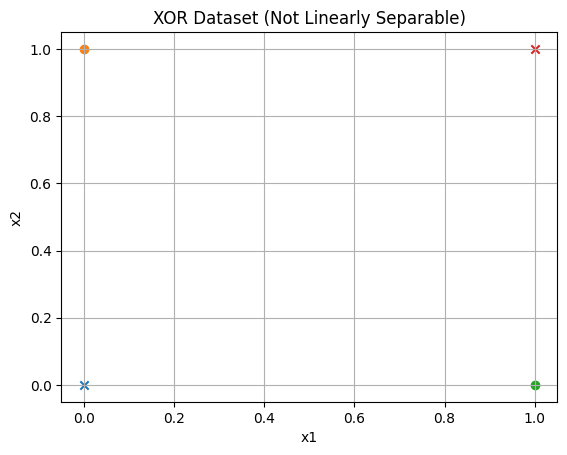

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Plot points
for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i,0], X[i,1], marker='o')
    else:
        plt.scatter(X[i,0], X[i,1], marker='x')

plt.title("XOR Dataset (Not Linearly Separable)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

# Simple Feedforward Network (Forward Pass)

In [8]:
import numpy as np

# Input
x = np.array([1.0, 2.0])

# Weights
W = np.array([[0.5, -0.2],
              [0.3, 0.8]])
b = np.array([0.1, -0.1])

U = np.array([[1.0, -1.0],
              [-0.5, 0.5]])

# Activation (ReLU)
def relu(z):
    return np.maximum(0, z)

# Softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

# Forward pass
h = relu(np.dot(W, x) + b)
z = np.dot(U, h)
y = softmax(z)

print("Hidden layer h:", h)
print("Output probabilities y:", y)

Hidden layer h: [0.2 1.8]
Output probabilities y: [0.0831727 0.9168273]


# Softmax Explanation

In [9]:
import numpy as np

z = np.array([2.0, 1.0, 0.1])

def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

probs = softmax(z)

print("Input logits:", z)
print("Softmax probabilities:", probs)
print("Sum:", np.sum(probs))

Input logits: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0


# Embedding Lookup

In [10]:
import numpy as np

# Vocabulary size = 5, embedding dim = 3
E = np.array([
    [0.1, 0.2, 0.3],  # word 0
    [0.5, 0.1, 0.0],  # word 1
    [0.0, 0.4, 0.6],  # word 2
    [0.9, 0.1, 0.2],  # word 3
    [0.3, 0.8, 0.5]   # word 4
])

# Word index (e.g., word "3")
word_index = 3

embedding = E[word_index]

print("Embedding matrix:\n", E)
print("Selected embedding for word index 3:", embedding)

Embedding matrix:
 [[0.1 0.2 0.3]
 [0.5 0.1 0. ]
 [0.  0.4 0.6]
 [0.9 0.1 0.2]
 [0.3 0.8 0.5]]
Selected embedding for word index 3: [0.9 0.1 0.2]


# Pooling vs Concatenation

In [11]:
import numpy as np

# 3 word embeddings (dim = 3)
embeddings = np.array([
    [0.1, 0.2, 0.3],
    [0.5, 0.1, 0.0],
    [0.0, 0.4, 0.6]
])

# Mean pooling
mean_pool = np.mean(embeddings, axis=0)

# Concatenation
concat = embeddings.flatten()

print("Embeddings:\n", embeddings)
print("\nMean pooled vector:", mean_pool)
print("\nConcatenated vector:", concat)
print("Concatenated shape:", concat.shape)

Embeddings:
 [[0.1 0.2 0.3]
 [0.5 0.1 0. ]
 [0.  0.4 0.6]]

Mean pooled vector: [0.2        0.23333333 0.3       ]

Concatenated vector: [0.1 0.2 0.3 0.5 0.1 0.  0.  0.4 0.6]
Concatenated shape: (9,)


# Backpropagation (Gradient Intuition)

In [12]:
import numpy as np

# Simple function: L = c * (a + 2b)

a, b, c = 3.0, 1.0, -2.0

# Forward pass
d = 2 * b
e = a + d
L = c * e

# Backward pass (manual gradients)
dL_dc = e
dL_de = c
de_da = 1
de_dd = 1
dd_db = 2

dL_da = dL_de * de_da
dL_db = dL_de * de_dd * dd_db

print("Loss:", L)
print("dL/da:", dL_da)
print("dL/db:", dL_db)
print("dL/dc:", dL_dc)

Loss: -10.0
dL/da: -2.0
dL/db: -4.0
dL/dc: 5.0
